# 🛰️ Satellite Data Analysis
## Data Engineering · Technical Analysis · Predictive Modeling · Visualization
---
**Dataset:** `satellites.csv` — Global active satellite registry  
**Author:** Data Science & Analytics  
**Source:** satellites_normalized.csv (normalized relational export)

https://www.kaggle.com/code/luisemiliani/starter-ucs-satellite-database


## 1. Imports & Global Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
import sqlite3
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print(" All libraries imported successfully")

 All libraries imported successfully


---
## 2. Data Engineering & Database Architecture


### 2.1 Load Raw Dataset

In [2]:
# Load raw satellites CSV
satellites_data = pd.read_csv('satellites.csv', sep=';', on_bad_lines='skip')

# Drop Source and Unnamed trailing columns
satellites_data = satellites_data.loc[:, ~satellites_data.columns.str.strip().str.match(r'^Source$')]
satellites_data = satellites_data.loc[:, ~satellites_data.columns.str.strip().str.match(r'^Unnamed.*')]
satellites_data = satellites_data.drop(columns=['Comments'], errors='ignore')
satellites_data.columns = satellites_data.columns.str.strip()


print(f"Shape: {satellites_data.shape}")
satellites_data.head()


Shape: (7560, 34)


,"Name of Satellite, Alternate Names",Current Official Name of Satellite,Country/Org of UN Registry,Country of Operator/Owner,Operator/Owner,Users,Purpose,Detailed Purpose,Class of Orbit,Type of Orbit,...,Launch Vehicle,COSPAR Number,NORAD Number,Source Used for Orbital Data,Source.1,Source.2,Source.3,Source.4,Source.5,Source.6
0,1HOPSAT-TD (1st-generation High Optical Perfor...,1HOPSAT-TD,NR,USA,Hera Systems,Commercial,Earth Observation,Infrared Imaging,LEO,Non-Polar Inclined,...,PSLV,2019-089H,44859,JMSatcat/3_20,https://www.herasys.com/,NaN,NaN,NaN,NaN,NaN
1,AAC AIS-Sat1 (Kelpie 1),AAC AIS-Sat1 (Kelpie 1),United Kingdom,United Kingdom,AAC Clyde Space,Commercial,Earth Observation,Automatic Identification System (AIS),LEO,Sun-Synchronous,...,Falcon 9,2023-001DC,55107,JMSatcat/9_23,NaN,NaN,NaN,NaN,NaN,NaN
2,Aalto-1,Aalto-1,Finland,Finland,Aalto University,Civil,Technology Development,NaN,LEO,Sun-Synchronous,...,PSLV,2017-036L,42775,JMSatcat/10_17,NaN,http://www.planet4589.org/space/log/satcat.txt,NaN,NaN,NaN,NaN
3,AAt-4,AAt-4,Denmark,Denmark,University of Aalborg,Civil,Earth Observation,Automatic Identification System (AIS),LEO,Sun-Synchronous,...,Soyuz-2.1a,2016-025E,41460,Space50,NaN,http://space50.org/objekt.php?mot=2016-025E&ja...,NaN,NaN,NaN,NaN
4,"ABS-2 (Koreasat-8, ST-3)",ABS-2,NR,Multinational,Asia Broadcast Satellite Ltd.,Commercial,Communications,NaN,GEO,NaN,...,Ariane 5 ECA,2014-006A,39508,ZARYA,NaN,http://www.zarya.info/Diaries/Launches/Launche...,http://www.absatellite.net/2010/10/13/asia-bro...,http://www.spacenews.com/article/satellite-tel...,NaN,NaN


### 2.2 Column Names

In [3]:
print(satellites_data.columns.tolist())


['Name of Satellite, Alternate Names', 'Current Official Name of Satellite', 'Country/Org of UN Registry', 'Country of Operator/Owner', 'Operator/Owner', 'Users', 'Purpose', 'Detailed Purpose', 'Class of Orbit', 'Type of Orbit', 'Longitude of GEO (degrees)', 'Perigee (km)', 'Apogee (km)', 'Eccentricity', 'Inclination (degrees)', 'Period (minutes)', 'Launch Mass (kg.)', 'Dry Mass (kg.)', 'Power (watts)', 'Date of Launch', 'Expected Lifetime (yrs.)', 'Contractor', 'Country of Contractor', 'Launch Site', 'Launch Vehicle', 'COSPAR Number', 'NORAD Number', 'Source Used for Orbital Data', 'Source.1', 'Source.2', 'Source.3', 'Source.4', 'Source.5', 'Source.6']


### 2.3 Data Sanitization
#### 2.3.1 Standardize Country Names

In [4]:
# Merge inconsistent country name variants
satellites_data['Country of Operator/Owner'] = satellites_data['Country of Operator/Owner'].replace({
    'USA':                      'United States',
    'US':                       'United States',
    'United States of America': 'United States'
})

print("Country standardization complete")
print(satellites_data['Country of Operator/Owner'].value_counts().head(5))


Country standardization complete
Country of Operator/Owner
United States     5165
United Kingdom     651
China              617
Russia             181
Japan               87
Name: count, dtype: int64


#### 2.3.2 Numeric Column Cleaning & Missing Value Imputation

In [5]:
numeric_cols = [
    'Perigee (km)', 'Apogee (km)', 'Eccentricity',
    'Inclination (degrees)', 'Period (minutes)',
    'Longitude of GEO (degrees)', 'Launch Mass (kg.)',
    'Dry Mass (kg.)', 'Power (watts)',
    'Expected Lifetime (yrs.)', 'NORAD Number'
]

for col in numeric_cols:
    if col in satellites_data.columns:
        satellites_data[col] = pd.to_numeric(
            satellites_data[col].astype(str).str.replace(',', '.').str.strip(),
            errors='coerce'
        )

print("Numeric columns cleaned")
satellites_data[numeric_cols[:5]].describe().round(2)


Numeric columns cleaned


,Perigee (km),Apogee (km),Eccentricity,Inclination (degrees),Period (minutes)
count,7553.00,7553.00,7549.00,7556.00,7504.00
mean,433.25,442.34,0.48,62.53,223.27
std,215.18,220.67,15.57,27.24,437.14
min,1.00,1.00,-0.03,0.00,5.58
25%,348.00,351.00,0.00,53.00,95.00
50%,538.00,541.00,0.00,53.20,95.60
75%,549.00,561.00,0.00,87.40,96.50
max,989.00,997.00,575.00,143.40,11520.00


#### 2.3.3 Median Imputation by Orbit Class

In [6]:
# Impute Launch Mass with group median per orbit class
satellites_data['Launch Mass (kg.)'] = (
    satellites_data.groupby('Class of Orbit')['Launch Mass (kg.)']
    .transform(lambda x: x.fillna(x.median()))
)

# Impute Expected Lifetime with group median per orbit class
satellites_data['Expected Lifetime (yrs.)'] = (
    satellites_data.groupby('Class of Orbit')['Expected Lifetime (yrs.)']
    .transform(lambda x: x.fillna(x.median()))
)

print("Missing values imputed by orbit class median")
print(f"  Launch Mass nulls remaining  : {satellites_data['Launch Mass (kg.)'].isna().sum()}")
print(f"  Expected Lifetime nulls remaining: {satellites_data['Expected Lifetime (yrs.)'].isna().sum()}")


Missing values imputed by orbit class median
  Launch Mass nulls remaining  : 0
  Expected Lifetime nulls remaining: 1


#### 2.3.4 ISO 8601 Date Conversion

In [7]:
# Convert Date of Launch to ISO 8601 (YYYY-MM-DD)
satellites_data['Date of Launch'] = pd.to_datetime(
    satellites_data['Date of Launch'], errors='coerce'
).dt.strftime('%Y-%m-%d')

print("Date converted to ISO 8601 format")
print(satellites_data[['Date of Launch', 'Expected Lifetime (yrs.)']].head(5))
print(f"\nDate of Launch dtype   : {satellites_data['Date of Launch'].dtype}")
print(f"Expected Lifetime dtype: {satellites_data['Expected Lifetime (yrs.)'].dtype}")


Date converted to ISO 8601 format
  Date of Launch  Expected Lifetime (yrs.)
0     2019-12-11                       0.5
1     2023-01-03                       4.0
2     2017-06-23                       2.0
3     2016-04-25                       4.0
4     2014-02-06                      15.0

Date of Launch dtype   : object
Expected Lifetime dtype: float64


---
## 3. Relational Schema — Normalized Database Structure

> Decompose the flat dataset into 6 normalized tables with enforced Primary and Foreign Keys.

```
countries (PK: country_id)
    │
    ├──► operators   (PK: operator_id,   FK: country_id)
    │
    └──► contractors (PK: contractor_id, FK: country_id)
                          │
launch_sites (PK: site_id)│
         │                │
         ▼                ▼
       satellites (PK: satellite_id, FK: operator_id, contractor_id, site_id, orbit_id)
         ▲
orbits (PK: orbit_id)
```


### 3.1 Build Dimension Tables

In [8]:
# ── TABLE 1: Countries (lookup) 
all_countries = pd.concat([
    satellites_data['Country of Operator/Owner'],
    satellites_data['Country of Contractor']
]).dropna().str.strip().unique()

countries = pd.DataFrame({
    'country_id':   range(1, len(all_countries) + 1),
    'country_name': sorted(all_countries)
})
country_map = dict(zip(countries['country_name'], countries['country_id']))

print(f"countries table  : {len(countries):>5} rows")
countries.head(5)


countries table  :   144 rows


,country_id,country_name
0,1,Algeria
1,2,Angola
2,3,Argentina
3,4,Australia
4,5,Austria


### 3.2 Operators Table

In [9]:
# ── TABLE 2: Operators (Organizational data) 
op_df = (satellites_data[['Operator/Owner', 'Country of Operator/Owner', 'Users']]
         .drop_duplicates('Operator/Owner').reset_index(drop=True))
op_df.insert(0, 'operator_id', range(1, len(op_df) + 1))
op_df['country_id'] = op_df['Country of Operator/Owner'].str.strip().map(country_map)
operators = op_df.rename(columns={
    'Operator/Owner':            'operator_name',
    'Country of Operator/Owner': 'country_name',
    'Users':                     'user_type'
})[['operator_id', 'operator_name', 'country_id', 'user_type']]
operator_map = dict(zip(operators['operator_name'], operators['operator_id']))

print(f"operators table  : {len(operators):>5} rows")
operators.head(5)


operators table  :   668 rows


,operator_id,operator_name,country_id,user_type
0,1,Hera Systems,141,Commercial
1,2,AAC Clyde Space,138,Commercial
2,3,Aalto University,34,Civil
3,4,University of Aalborg,25,Civil
4,5,Asia Broadcast Satellite Ltd.,83,Commercial


### 3.3 Contractors Table

In [10]:
con_df = (satellites_data[['Contractor', 'Country of Contractor']]
          .drop_duplicates('Contractor').reset_index(drop=True))
con_df.insert(0, 'contractor_id', range(1, len(con_df) + 1))
con_df['country_id'] = con_df['Country of Contractor'].str.strip().map(country_map)
contractors = con_df.rename(columns={
    'Contractor':            'contractor_name',
    'Country of Contractor': 'country_name'
})[['contractor_id', 'contractor_name', 'country_id']]
contractor_map = dict(zip(contractors['contractor_name'], contractors['contractor_id']))

print(f"contractors table: {len(contractors):>5} rows")
contractors.head(5)


contractors table:   577 rows


,contractor_id,contractor_name,country_id
0,1,Hera Systems,125
1,2,AAC Clyde Space,112
2,3,Aalto University,34
3,4,University of Aalborg,25
4,5,Space Systems/Loral,125


### 3.4 Launch Sites Table

In [11]:
# ── TABLE 4: Launch Sites (lookup) 
site_df = (satellites_data[['Launch Site']].drop_duplicates().dropna()
           .reset_index(drop=True))
site_df.insert(0, 'site_id', range(1, len(site_df) + 1))
launch_sites = site_df.rename(columns={'Launch Site': 'site_name'})
site_map = dict(zip(launch_sites['site_name'], launch_sites['site_id']))

print(f"launch_sites table: {len(launch_sites):>4} rows")
launch_sites.head(5)


launch_sites table:   40 rows


,site_id,site_name
0,1,Satish Dhawan Space Centre
1,2,Cape Canaveral
2,3,Guiana Space Center
3,4,Baikonur Cosmodrome
4,5,Vandenberg AFB


### 3.5 Orbits Table (Orbital Dynamics)

In [12]:
# ── TABLE 5: Orbits (Orbital dynamics) 
orbit_cols = [
    'Class of Orbit', 'Type of Orbit', 'Longitude of GEO (degrees)',
    'Perigee (km)', 'Apogee (km)', 'Eccentricity',
    'Inclination (degrees)', 'Period (minutes)'
]
orbit_df = satellites_data[orbit_cols].drop_duplicates().reset_index(drop=True)
orbit_df.insert(0, 'orbit_id', range(1, len(orbit_df) + 1))
orbits = orbit_df.rename(columns={
    'Class of Orbit':             'orbit_class',
    'Type of Orbit':              'orbit_type',
    'Longitude of GEO (degrees)': 'longitude_geo_deg',
    'Perigee (km)':               'perigee_km',
    'Apogee (km)':                'apogee_km',
    'Eccentricity':               'eccentricity',
    'Inclination (degrees)':      'inclination_deg',
    'Period (minutes)':           'period_min'
})
orbit_key       = satellites_data[orbit_cols].apply(tuple, axis=1)
orbit_lookup    = {tuple(row[1:]): row[0] for row in orbits.itertuples(index=False)}
orbit_id_series = orbit_key.map(orbit_lookup)

print(f"orbits table     : {len(orbits):>5} rows")
orbits.head(5)


orbits table     :  2556 rows


,orbit_id,orbit_class,orbit_type,longitude_geo_deg,perigee_km,apogee_km,eccentricity,inclination_deg,period_min
0,1,LEO,Non-Polar Inclined,0.0,566.000,576.000,0.001510,36.90,96.08
1,2,LEO,Sun-Synchronous,0.0,637.000,654.000,0.001510,98.00,95.00
2,3,LEO,Sun-Synchronous,0.0,497.000,517.000,0.001450,97.45,94.70
3,4,LEO,Sun-Synchronous,0.0,442.000,687.000,0.001510,98.20,95.90
4,5,GEO,NaN,75.0,35.778,35.793,0.000178,0.08,1436.03


### 3.6 Satellites Fact Table (Technical Specs)

In [13]:
# ── TABLE 6: Satellites (Technical specs — FACT TABLE) 
satellites_table = pd.DataFrame({
    'satellite_id':          range(1, len(satellites_data) + 1),
    'official_name':         satellites_data['Current Official Name of Satellite'].str.strip(),
    'alternate_names':       satellites_data['Name of Satellite, Alternate Names'].str.strip(),
    'cospar_number':         satellites_data['COSPAR Number'],
    'norad_number':          satellites_data['NORAD Number'],
    'operator_id':           satellites_data['Operator/Owner'].str.strip().map(operator_map),
    'contractor_id':         satellites_data['Contractor'].str.strip().map(contractor_map),
    'site_id':               satellites_data['Launch Site'].str.strip().map(site_map),
    'orbit_id':              orbit_id_series.values,
    'purpose':               satellites_data['Purpose'],
    'detailed_purpose':      satellites_data['Detailed Purpose'],
    'launch_vehicle':        satellites_data['Launch Vehicle'],
    'date_of_launch':        satellites_data['Date of Launch'],
    'expected_lifetime_yrs': satellites_data['Expected Lifetime (yrs.)'],
    'launch_mass_kg':        satellites_data['Launch Mass (kg.)'],
    'dry_mass_kg':           satellites_data['Dry Mass (kg.)'],
    'power_watts':           satellites_data['Power (watts)'],
})

print(f"satellites table : {len(satellites_table):>5} rows")
satellites_table.head(5)


satellites table :  7560 rows


,satellite_id,official_name,alternate_names,cospar_number,norad_number,operator_id,contractor_id,site_id,orbit_id,purpose,detailed_purpose,launch_vehicle,date_of_launch,expected_lifetime_yrs,launch_mass_kg,dry_mass_kg,power_watts
0,1,1HOPSAT-TD,1HOPSAT-TD (1st-generation High Optical Perfor...,2019-089H,44859,1.0,1.0,1.0,1,Earth Observation,Infrared Imaging,PSLV,2019-12-11,0.5,22.00,NaN,NaN
1,2,AAC AIS-Sat1 (Kelpie 1),AAC AIS-Sat1 (Kelpie 1),2023-001DC,55107,2.0,2.0,2.0,2,Earth Observation,Automatic Identification System (AIS),Falcon 9,2023-01-03,4.0,4.00,4.0,NaN
2,3,Aalto-1,Aalto-1,2017-036L,42775,3.0,3.0,1.0,3,Technology Development,NaN,PSLV,2017-06-23,2.0,5.00,NaN,4.5
3,4,AAt-4,AAt-4,2016-025E,41460,4.0,4.0,3.0,4,Earth Observation,Automatic Identification System (AIS),Soyuz-2.1a,2016-04-25,4.0,1.00,NaN,NaN
4,5,ABS-2,"ABS-2 (Koreasat-8, ST-3)",2014-006A,39508,5.0,5.0,3.0,5,Communications,NaN,Ariane 5 ECA,2014-02-06,15.0,6.33,NaN,NaN


### 3.7 Write to SQLite — Enforce PK & FK Constraints

In [14]:
conn = sqlite3.connect("satellites_normalized.db")
conn.execute("PRAGMA foreign_keys = ON")
cur = conn.cursor()

for tbl in ['satellites', 'orbits', 'launch_sites', 'contractors', 'operators', 'countries']:
    cur.execute(f"DROP TABLE IF EXISTS {tbl}")

cur.executescript("""
    CREATE TABLE countries (
        country_id   INTEGER PRIMARY KEY,
        country_name TEXT    NOT NULL UNIQUE
    );
    CREATE TABLE operators (
        operator_id   INTEGER PRIMARY KEY,
        operator_name TEXT    NOT NULL,
        country_id    INTEGER NOT NULL,
        user_type     TEXT,
        FOREIGN KEY (country_id) REFERENCES countries(country_id)
    );
    CREATE TABLE contractors (
        contractor_id   INTEGER PRIMARY KEY,
        contractor_name TEXT    NOT NULL,
        country_id      INTEGER NOT NULL,
        FOREIGN KEY (country_id) REFERENCES countries(country_id)
    );
    CREATE TABLE launch_sites (
        site_id   INTEGER PRIMARY KEY,
        site_name TEXT    NOT NULL UNIQUE
    );
    CREATE TABLE orbits (
        orbit_id          INTEGER PRIMARY KEY,
        orbit_class       TEXT,
        orbit_type        TEXT,
        longitude_geo_deg REAL,
        perigee_km        REAL,
        apogee_km         REAL,
        eccentricity      REAL,
        inclination_deg   REAL,
        period_min        REAL
    );
    CREATE TABLE satellites (
        satellite_id          INTEGER PRIMARY KEY,
        official_name         TEXT,
        alternate_names       TEXT,
        cospar_number         TEXT,
        norad_number          REAL,
        operator_id           INTEGER,
        contractor_id         INTEGER,
        site_id               INTEGER,
        orbit_id              INTEGER,
        purpose               TEXT,
        detailed_purpose      TEXT,
        launch_vehicle        TEXT,
        date_of_launch        TEXT,
        expected_lifetime_yrs REAL,
        launch_mass_kg        REAL,
        dry_mass_kg           REAL,
        power_watts           REAL,
        FOREIGN KEY (operator_id)   REFERENCES operators(operator_id),
        FOREIGN KEY (contractor_id) REFERENCES contractors(contractor_id),
        FOREIGN KEY (site_id)       REFERENCES launch_sites(site_id),
        FOREIGN KEY (orbit_id)      REFERENCES orbits(orbit_id)
    );
""")

countries.to_sql('countries',         conn, if_exists='append', index=False)
operators.to_sql('operators',         conn, if_exists='append', index=False)
contractors.to_sql('contractors',     conn, if_exists='append', index=False)
launch_sites.to_sql('launch_sites',   conn, if_exists='append', index=False)
orbits.to_sql('orbits',               conn, if_exists='append', index=False)
satellites_table.to_sql('satellites', conn, if_exists='append', index=False)
conn.commit()
print("SQLite database created: satellites_normalized.db")


SQLite database created: satellites_normalized.db


### 3.8 FK Integrity Check

In [15]:
print(f"{'Table':<15} {'Rows':>6}")
print("-" * 22)
for tbl in ['countries', 'operators', 'contractors', 'launch_sites', 'orbits', 'satellites']:
    count = conn.execute(f"SELECT COUNT(*) FROM {tbl}").fetchone()[0]
    print(f"{tbl:<15} {count:>6}")

print("\n FK Integrity Check")
checks = {
    "satellites → operators":    "SELECT COUNT(*) FROM satellites WHERE operator_id   NOT IN (SELECT operator_id   FROM operators)",
    "satellites → contractors":  "SELECT COUNT(*) FROM satellites WHERE contractor_id NOT IN (SELECT contractor_id FROM contractors)",
    "satellites → launch_sites": "SELECT COUNT(*) FROM satellites WHERE site_id       NOT IN (SELECT site_id       FROM launch_sites)",
    "satellites → orbits":       "SELECT COUNT(*) FROM satellites WHERE orbit_id      NOT IN (SELECT orbit_id      FROM orbits)",
}
for label, query in checks.items():
    broken = conn.execute(query).fetchone()[0]
    status = "OK" if broken == 0 else f"❌ {broken} broken"
    print(f"  {label:<30} {status}")
conn.close()


Table             Rows
----------------------
countries          144
operators          668
contractors        577
launch_sites        40
orbits            2556
satellites        7560

 FK Integrity Check
  satellites → operators         OK
  satellites → contractors       OK
  satellites → launch_sites      OK
  satellites → orbits            OK


### 3.9 Export Normalized CSV (Merged Flat File)

In [16]:
conn = sqlite3.connect("satellites_normalized.db")

df = pd.read_sql_query("""
    SELECT
        s.*,
        op.operator_name, op.user_type,
        con.contractor_name,
        ls.site_name,
        o.orbit_class, o.orbit_type, o.perigee_km, o.apogee_km,
        o.eccentricity, o.inclination_deg, o.period_min,
        c.country_name AS operator_country
    FROM satellites s
    LEFT JOIN operators   op  ON s.operator_id   = op.operator_id
    LEFT JOIN contractors con ON s.contractor_id  = con.contractor_id
    LEFT JOIN launch_sites ls ON s.site_id        = ls.site_id
    LEFT JOIN orbits       o  ON s.orbit_id       = o.orbit_id
    LEFT JOIN countries    c  ON op.country_id    = c.country_id
""", conn)

df.to_csv("satellites_normalized.csv", index=False)
conn.close()

print(f"satellites_normalized.csv → {len(df):,} rows, {df.shape[1]} cols")
df.head(5)


satellites_normalized.csv → 7,560 rows, 29 cols


,satellite_id,official_name,alternate_names,cospar_number,norad_number,operator_id,contractor_id,site_id,orbit_id,purpose,...,contractor_name,site_name,orbit_class,orbit_type,perigee_km,apogee_km,eccentricity,inclination_deg,period_min,operator_country
0,1,1HOPSAT-TD,1HOPSAT-TD (1st-generation High Optical Perfor...,2019-089H,44859.0,1.0,1.0,1.0,1,Earth Observation,...,Hera Systems,Satish Dhawan Space Centre,LEO,Non-Polar Inclined,566.000,576.000,0.001510,36.90,96.08,United States
1,2,AAC AIS-Sat1 (Kelpie 1),AAC AIS-Sat1 (Kelpie 1),2023-001DC,55107.0,2.0,2.0,2.0,2,Earth Observation,...,AAC Clyde Space,Cape Canaveral,LEO,Sun-Synchronous,637.000,654.000,0.001510,98.00,95.00,United Kingdom
2,3,Aalto-1,Aalto-1,2017-036L,42775.0,3.0,3.0,1.0,3,Technology Development,...,Aalto University,Satish Dhawan Space Centre,LEO,Sun-Synchronous,497.000,517.000,0.001450,97.45,94.70,Finland
3,4,AAt-4,AAt-4,2016-025E,41460.0,4.0,4.0,3.0,4,Earth Observation,...,University of Aalborg,Guiana Space Center,LEO,Sun-Synchronous,442.000,687.000,0.001510,98.20,95.90,Denmark
4,5,ABS-2,"ABS-2 (Koreasat-8, ST-3)",2014-006A,39508.0,5.0,5.0,3.0,5,Communications,...,Space Systems/Loral,Guiana Space Center,GEO,None,35.778,35.793,0.000178,0.08,1436.03,Multinational


---
## 4. Technical & Competitive Analysis


### 4.1 Regional Benchmarking — Caspian / Caucasus Market
> Comparative analysis: Azerbaijan vs. Turkey, Kazakhstan, Iran


#### 4.1.1 Data Preparation & Aggregations

In [17]:
df = pd.read_csv("satellites_normalized.csv")
df['orbit_class'] = df['orbit_class'].replace({'LEo': 'LEO'})

TARGET     = ['Turkey', 'Kazakhstan', 'Iran', 'Azerbaijan']
region     = df[df['operator_country'].isin(TARGET)].copy()
region['Country'] = region['operator_country']

COUNTRIES  = ['Turkey', 'Kazakhstan', 'Iran', 'Azerbaijan']
COLORS     = {'Turkey': '#378ADD', 'Kazakhstan': '#1D9E75',
              'Iran': '#E24B4A', 'Azerbaijan': "#CCDD77"}
color_list = [COLORS[c] for c in COUNTRIES]

sat_count    = region['Country'].value_counts().reindex(COUNTRIES).fillna(0).astype(int)
total_mass   = region.groupby('Country')['launch_mass_kg'].sum().reindex(COUNTRIES).fillna(0)
avg_mass     = region.groupby('Country')['launch_mass_kg'].mean().reindex(COUNTRIES).fillna(0)
avg_lifetime = region.groupby('Country')['expected_lifetime_yrs'].mean().reindex(COUNTRIES)
purpose_ct   = pd.crosstab(region['Country'], region['purpose']).reindex(COUNTRIES).fillna(0)
users_ct     = pd.crosstab(region['Country'], region['user_type']).reindex(COUNTRIES).fillna(0)
orbit_ct     = pd.crosstab(region['Country'], region['orbit_class']).reindex(COUNTRIES).fillna(0)

print("Satellite count by country:")
print(sat_count)
print("\nPurpose distribution:")
print(purpose_ct)


Satellite count by country:
Country
Turkey        14
Kazakhstan     6
Iran           2
Azerbaijan     2
Name: count, dtype: int32

Purpose distribution:
purpose     Communications  Earth Observation  Technology Development
Country                                                              
Turkey                   7                  6                       1
Kazakhstan               2                  3                       1
Iran                     0                  2                       0
Azerbaijan               2                  0                       0


#### 4.1.2 Chart 1 — Comparative Bar Chart

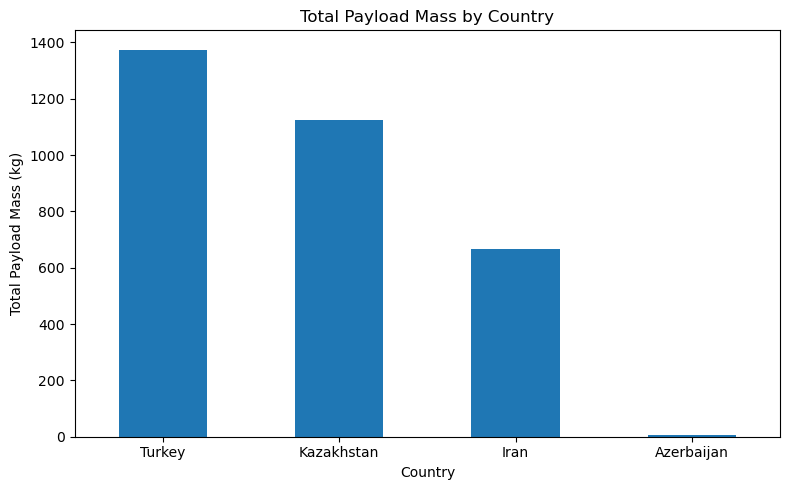

<Figure size 1200x600 with 0 Axes>

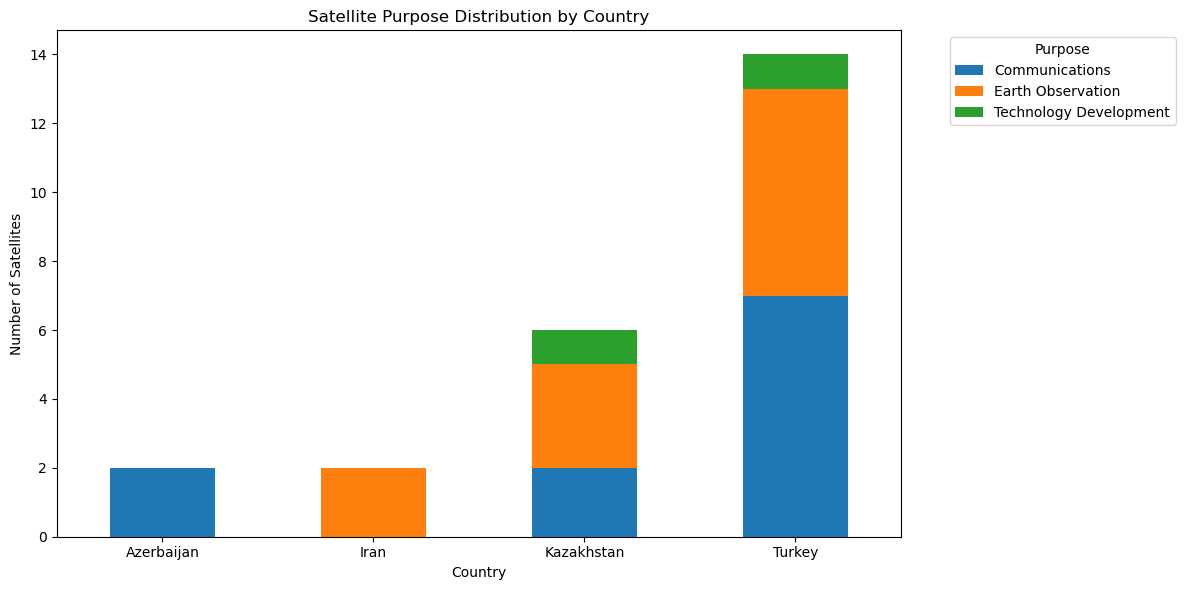

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("satellites_normalized.csv")
# Regional Competitors
countries = ['Azerbaijan', 'Turkey', 'Kazakhstan', 'Iran']

regional_df = df[df['operator_country'].isin(countries)].copy()


payload_mass = (
    regional_df.groupby('operator_country')['launch_mass_kg']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
payload_mass.plot(kind='bar')

plt.title("Total Payload Mass by Country")
plt.xlabel("Country")
plt.ylabel("Total Payload Mass (kg)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

#----------------------------------------------------------------------------------------------------
purpose_distribution = (
    regional_df.groupby(['operator_country', 'purpose'])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12,6))

purpose_distribution.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Satellite Purpose Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Satellites")
plt.xticks(rotation=0)

plt.legend(title="Purpose", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()

user_type         Civil  Commercial  Commercial/Civil  Government  Military
operator_country                                                           
Azerbaijan            0           0                 0           2         0
Iran                  0           0                 0           0         2
Kazakhstan            1           3                 0           2         0
Turkey                3           7                 1           1         2


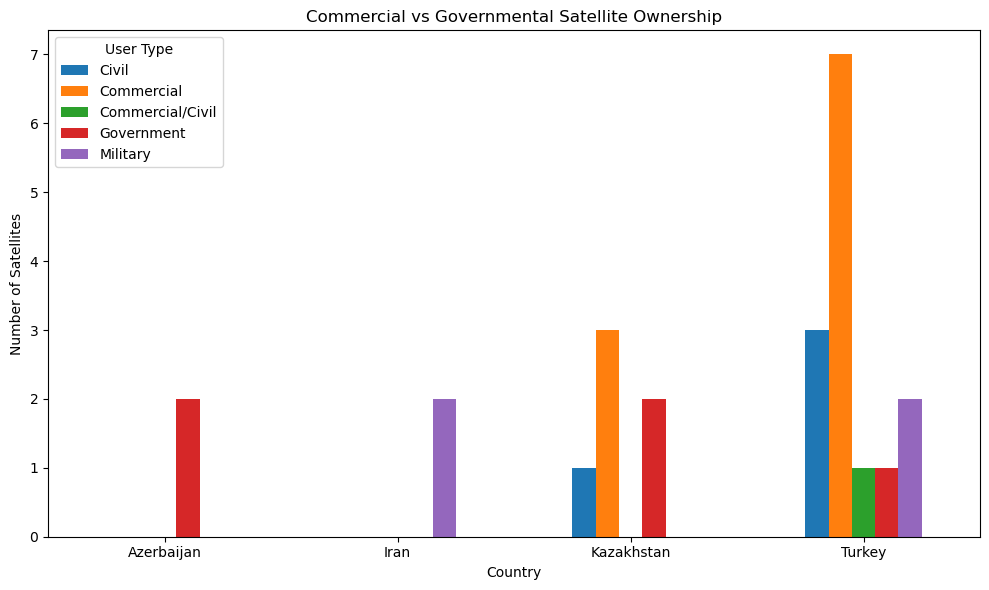

In [19]:
df = pd.read_csv("satellites_normalized.csv")
countries = ['Azerbaijan', 'Turkey', 'Kazakhstan', 'Iran']

regional_df = df[df['operator_country'].isin(countries)].copy()

# Group satellites by country and ownership type
ownership = (
    regional_df.groupby(['operator_country', 'user_type'])
    .size()
    .unstack(fill_value=0)
)

print(ownership)

ownership.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Commercial vs Governmental Satellite Ownership")
plt.xlabel("Country")
plt.ylabel("Number of Satellites")

plt.xticks(rotation=0)

plt.legend(title="User Type")
plt.tight_layout()

plt.show()

### 4.2 Orbital Mechanics & Mission Analysis
> Mass-to-Life Ratio · Eccentricity Classification · Degradation Trends


#### 4.2.1 Derive Orbital Features

In [20]:
from scipy import stats

df = pd.read_csv("satellites_normalized.csv")
df['orbit_class'] = df['orbit_class'].replace({'LEo': 'LEO'})

# Feature 1: Derived Eccentricity  e = (Apogee - Perigee) / (Apogee + Perigee)
df['Derived_Eccentricity'] = (
    (df['apogee_km'] - df['perigee_km']) /
    (df['apogee_km'] + df['perigee_km'])
)

# Feature 2: Orbit stability category
def classify_eccentricity(e):
    if pd.isna(e):   return 'Unknown'
    elif e < 0.01:   return 'Circular (stable)'
    elif e < 0.10:   return 'Near-circular'
    elif e < 0.50:   return 'Elliptical'
    else:            return 'Highly elliptical'

df['Orbit_Stability'] = df['Derived_Eccentricity'].apply(classify_eccentricity)

# Feature 3: Actual time in orbit (years)
df['date_of_launch'] = pd.to_datetime(df['date_of_launch'], errors='coerce')
today = pd.Timestamp('2026-04-24')
df['Actual_Time_in_Orbit'] = (today - df['date_of_launch']).dt.days / 365.25

# Feature 4: Mass-to-Life Ratio
df['Mass_to_Life_Ratio'] = df['launch_mass_kg'] / df['expected_lifetime_yrs']

# Feature 5: Degradation Gap (negative = exceeded expected lifetime)
df['Degradation_Gap'] = df['expected_lifetime_yrs'] - df['Actual_Time_in_Orbit']

print("Orbit stability distribution:")
print(df['Orbit_Stability'].value_counts())
print("\nDegradation by purpose:")
print(df.groupby('purpose').agg(
    Avg_Expected=('expected_lifetime_yrs','mean'),
    Avg_Actual=('Actual_Time_in_Orbit','mean'),
    Avg_Gap=('Degradation_Gap','mean'),
    Count=('purpose','count')
).round(2))


Orbit stability distribution:
Orbit_Stability
Circular (stable)    4903
Near-circular        2540
Elliptical             71
Highly elliptical      39
Unknown                 7
Name: count, dtype: int64

Degradation by purpose:
                                                Avg_Expected  Avg_Actual  \
purpose                                                                    
Communications                                          5.24        5.68   
Communications/Maritime Tracking                        4.00       13.92   
Communications/Navigation                              12.00       14.93   
Communications/Technology Development                   6.75       18.28   
Earth Observation                                       4.51        7.93   
Earth Observation                                       4.67        8.07   
Earth Observation/Communications                        9.50       13.73   
Earth Observation/Communications/Space Science          3.00       11.33   
Earth Observa

Correlation between Launch Mass and Expected Lifetime: -0.04


<Figure size 800x500 with 0 Axes>

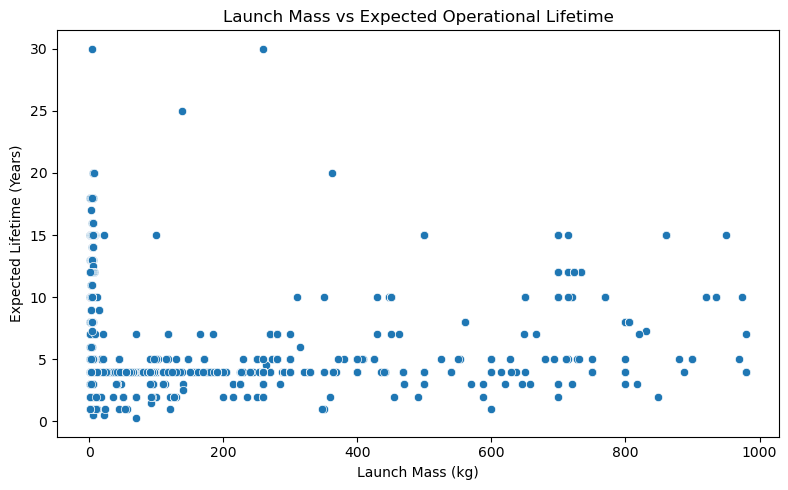

In [22]:
import seaborn as sns
df = pd.read_csv("satellites_normalized.csv")
mass_life_df = df.dropna(
    subset=['launch_mass_kg', 'expected_lifetime_yrs']
).copy()


correlation = mass_life_df['launch_mass_kg'].corr(
    mass_life_df['expected_lifetime_yrs']
)

print(f"Correlation between Launch Mass and Expected Lifetime: {correlation:.2f}")

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=mass_life_df,
    x='launch_mass_kg',
    y='expected_lifetime_yrs'
)

plt.title("Launch Mass vs Expected Operational Lifetime")
plt.xlabel("Launch Mass (kg)")
plt.ylabel("Expected Lifetime (Years)")

plt.tight_layout()
plt.show()

#### 4.2.2 Chart 2 — Perigee vs Apogee Scatter

   perigee_km  apogee_km  eccentricity    orbit_stability
0     566.000    576.000      0.008757      Highly Stable
1     637.000    654.000      0.013168  Moderately Stable
2     497.000    517.000      0.019724  Moderately Stable
3     442.000    687.000      0.217006        Less Stable
4      35.778     35.793      0.000210      Highly Stable


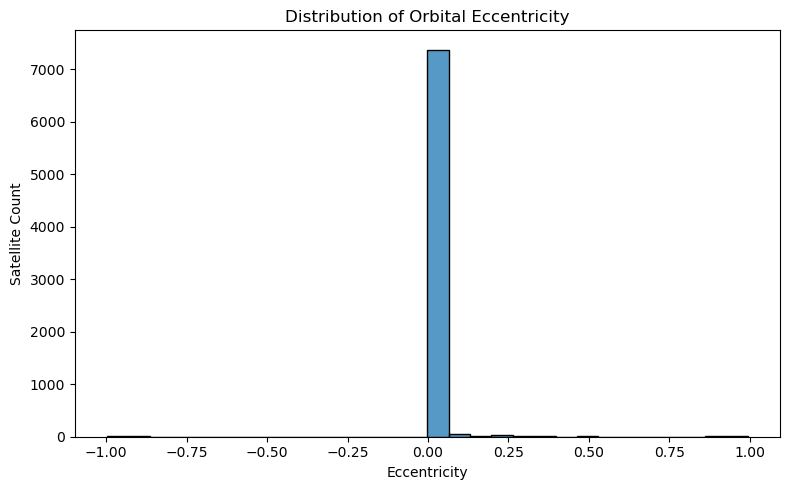

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

# ── Load & prepare 
df = pd.read_csv("satellites_normalized.csv")
orbit_df = df.dropna(subset=['apogee_km', 'perigee_km']).copy()

# Calculate Orbital Eccentricity
orbit_df['eccentricity'] = (
    (orbit_df['apogee_km'] - orbit_df['perigee_km']) /
    (orbit_df['apogee_km'] + orbit_df['perigee_km'])
)

# Categorize orbital stability
def classify_stability(e):
    if e < 0.01:
        return 'Highly Stable'
    elif e < 0.1:
        return 'Moderately Stable'
    else:
        return 'Less Stable'

orbit_df['orbit_stability'] = orbit_df['eccentricity'].apply(classify_stability)

# Show sample
print(
    orbit_df[
        ['perigee_km', 'apogee_km', 'eccentricity', 'orbit_stability']
    ].head()
)

plt.figure(figsize=(8,5))

sns.histplot(
    data=orbit_df,
    x='eccentricity',
    bins=30
)

plt.title("Distribution of Orbital Eccentricity")
plt.xlabel("Eccentricity")
plt.ylabel("Satellite Count")

plt.tight_layout()
plt.show()



### 4.3 Launch Provider Efficiency
> Top 10 vehicles · Orbit destination mix · 15-year mass trend


#### 4.3.1 Data Preparation

In [24]:
# Launch Provider Efficiency — clean data preparation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REGIONAL_COUNTRIES = ['Azerbaijan', 'Turkey', 'Kazakhstan', 'Iran']

launch_df = pd.read_csv("satellites_normalized.csv")

# Standard cleanup used in this section
launch_df['date_of_launch'] = pd.to_datetime(launch_df['date_of_launch'], errors='coerce')
launch_df['year'] = launch_df['date_of_launch'].dt.year
launch_df['orbit_class'] = launch_df['orbit_class'].replace({'LEo': 'LEO', 'leo': 'LEO', 'Geo': 'GEO', 'Meo': 'MEO'})

# Keep realistic years only
launch_df = launch_df[launch_df['year'].between(1957, 2024)].copy()

# Clean launch vehicle values
launch_df['launch_vehicle'] = (
    launch_df['launch_vehicle']
    .replace(['-', 'Unknown', 'unknown', ''], np.nan)
    .fillna('Unknown')
)

# Top 10 launch vehicles by number of satellites placed in orbit
top10_vehicles = launch_df['launch_vehicle'].value_counts().head(10).index.tolist()
top10_df = launch_df[launch_df['launch_vehicle'].isin(top10_vehicles)].copy()

print("Top 10 launch vehicles by satellite count:")
print(launch_df['launch_vehicle'].value_counts().head(10))

print("\nNote: The UCS dataset mainly includes satellites that reached orbit. Therefore, this project treats 'efficiency' as successful orbital placement distribution by orbit class, not failed launch rate.")

Top 10 launch vehicles by satellite count:
launch_vehicle
Falcon 9         4731
Soyuz-2.1b        475
PSLV              189
Long March 2D     147
Atlas 5           114
Electron          102
Ariane 5           95
Soyuz-2.1a         88
Long March 3B      86
Long March 2C      79
Name: count, dtype: int64

Note: The UCS dataset mainly includes satellites that reached orbit. Therefore, this project treats 'efficiency' as successful orbital placement distribution by orbit class, not failed launch rate.


#### 4.3.2 Chart 3 — Launch Provider Efficiency

=== Top 10 Launch Vehicle Summary ===


,satellites_placed,avg_launch_mass_kg,total_launch_mass_kg
launch_vehicle,,,
Falcon 9,4731,246.34,1165415.46
Soyuz-2.1b,475,136.96,65054.81
PSLV,189,97.06,18344.57
Long March 2D,147,183.48,26972.01
Atlas 5,114,51.78,5902.89
Electron,102,31.37,3200.00
Ariane 5,95,64.36,6113.95
Soyuz-2.1a,88,101.79,8957.20
Long March 3B,86,283.08,24344.65


=== Orbit Placement Counts by Launch Vehicle ===


orbit_class,Elliptical,GEO,LEO,MEO
launch_vehicle,,,,
Ariane 5,1,85,1,8
Atlas 5,11,47,49,7
Electron,0,0,102,0
Falcon 9,1,46,4679,5
Long March 2C,0,0,79,0
Long March 2D,0,0,147,0
Long March 3B,0,55,2,29
PSLV,0,4,185,0
Soyuz-2.1a,7,0,80,1


=== Orbit Placement Share (%) by Launch Vehicle ===


orbit_class,Elliptical,GEO,LEO,MEO
launch_vehicle,,,,
Ariane 5,1.1,89.5,1.1,8.4
Atlas 5,9.6,41.2,43.0,6.1
Electron,0.0,0.0,100.0,0.0
Falcon 9,0.0,1.0,98.9,0.1
Long March 2C,0.0,0.0,100.0,0.0
Long March 2D,0.0,0.0,100.0,0.0
Long March 3B,0.0,64.0,2.3,33.7
PSLV,0.0,2.1,97.9,0.0
Soyuz-2.1a,8.0,0.0,90.9,1.1


=== Average Payload Mass Trend: 2009–2023 ===


,year,avg_mass,total_mass,satellite_count
0,2009.0,50.01,2850.39,57
1,2010.0,137.10,9048.35,66
2,2011.0,186.68,15680.81,84
3,2012.0,136.06,10748.77,79
4,2013.0,178.13,16922.70,95
5,2014.0,157.74,18455.35,117
6,2015.0,111.76,14752.30,132
7,2016.0,144.17,15425.80,107
8,2017.0,221.42,48932.79,221
9,2018.0,214.26,65993.44,308


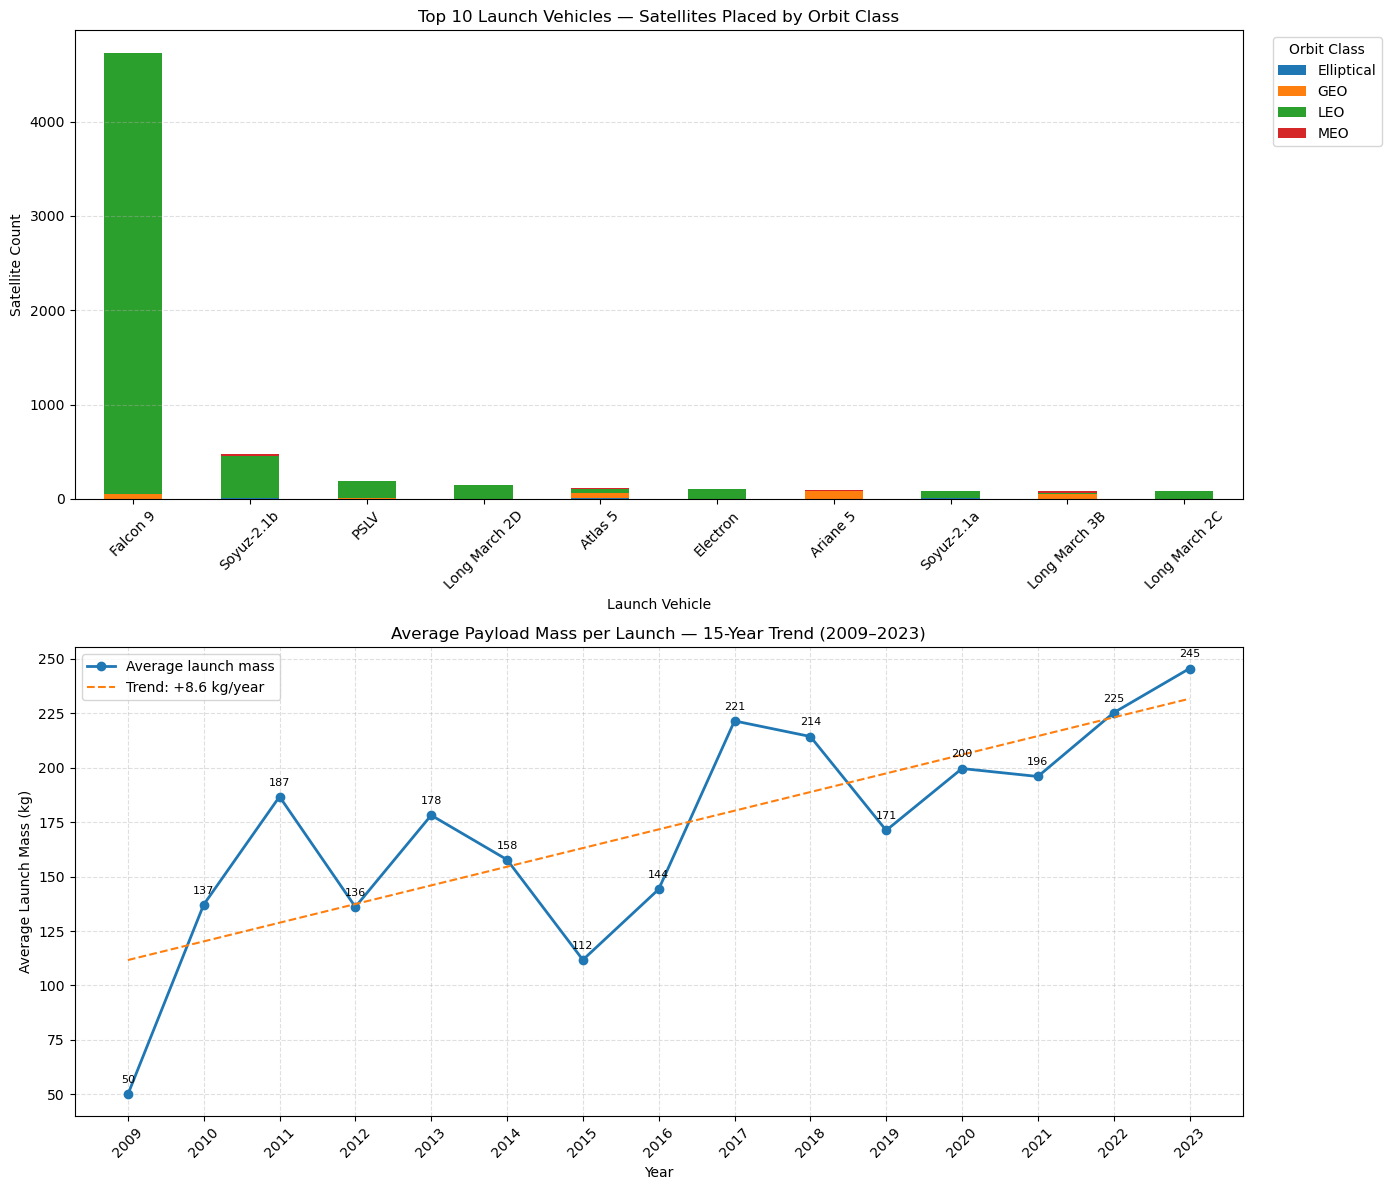

Saved: launch_provider_efficiency.png
Saved: top10_launch_vehicle_summary.csv
Saved: top10_launch_vehicle_orbit_counts.csv
Saved: top10_launch_vehicle_orbit_share_percent.csv


In [26]:
# Launch Provider Efficiency — top 10 vehicles, orbit mix, and 15-year mass trend

# 1) Orbit destination mix for top 10 launch vehicles
orbit_mix = pd.crosstab(
    top10_df['launch_vehicle'],
    top10_df['orbit_class'],
    normalize='index'
).mul(100).round(1)

orbit_counts = pd.crosstab(
    top10_df['launch_vehicle'],
    top10_df['orbit_class']
)

vehicle_summary = (
    top10_df.groupby('launch_vehicle')
    .agg(
        satellites_placed=('official_name', 'count'),
        avg_launch_mass_kg=('launch_mass_kg', 'mean'),
        total_launch_mass_kg=('launch_mass_kg', 'sum')
    )
    .sort_values('satellites_placed', ascending=False)
    .round(2)
)

print("=== Top 10 Launch Vehicle Summary ===")
display(vehicle_summary)

print("=== Orbit Placement Counts by Launch Vehicle ===")
display(orbit_counts)

print("=== Orbit Placement Share (%) by Launch Vehicle ===")
display(orbit_mix)

# Save analytical tables for report use
vehicle_summary.to_csv('top10_launch_vehicle_summary.csv')
orbit_counts.to_csv('top10_launch_vehicle_orbit_counts.csv')
orbit_mix.to_csv('top10_launch_vehicle_orbit_share_percent.csv')

# 2) Average mass per launch over the last 15 years in the dataset
trend_df = launch_df[launch_df['year'].between(2009, 2023)].copy()

yearly_mass = (
    trend_df.groupby('year')
    .agg(
        avg_mass=('launch_mass_kg', 'mean'),
        total_mass=('launch_mass_kg', 'sum'),
        satellite_count=('launch_mass_kg', 'count')
    )
    .reset_index()
)

print("=== Average Payload Mass Trend: 2009–2023 ===")
display(yearly_mass.round(2))

years = yearly_mass['year'].astype(int)
avg_mass = yearly_mass['avg_mass']
counts = yearly_mass['satellite_count']

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Chart A — Top 10 launch vehicle orbit mix
orbit_counts.loc[vehicle_summary.index].plot(
    kind='bar',
    stacked=True,
    ax=axes[0]
)
axes[0].set_title('Top 10 Launch Vehicles — Satellites Placed by Orbit Class')
axes[0].set_xlabel('Launch Vehicle')
axes[0].set_ylabel('Satellite Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Orbit Class', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Chart B — 15-year mass trend
axes[1].plot(years, avg_mass, marker='o', linewidth=2, label='Average launch mass')

if len(years) >= 2:
    z = np.polyfit(years, avg_mass, 1)
    p = np.poly1d(z)
    axes[1].plot(years, p(years), '--', label=f'Trend: {z[0]:+.1f} kg/year')

for year, mass, count in zip(years, avg_mass, counts):
    axes[1].annotate(
        f'{mass:.0f}',
        xy=(year, mass),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=8
    )

axes[1].set_title('Average Payload Mass per Launch — 15-Year Trend (2009–2023)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Launch Mass (kg)')
axes[1].set_xticks(years)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, linestyle='--', alpha=0.4)
axes[1].legend()

plt.tight_layout()
plt.savefig('launch_provider_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: launch_provider_efficiency.png")
print("Saved: top10_launch_vehicle_summary.csv")
print("Saved: top10_launch_vehicle_orbit_counts.csv")
print("Saved: top10_launch_vehicle_orbit_share_percent.csv")

---
## 5. Predictive Modeling — Orbit Class Classification
> Build a classification model to predict LEO / MEO / GEO  
> Features: Period (min) · Inclination (°) · Launch Mass (kg)  
> Validation: Confusion matrix + classification report


### 5.1 Install & Import ML Libraries

In [27]:
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics         import confusion_matrix, classification_report, accuracy_score
from sklearn.pipeline        import Pipeline

print(" scikit-learn imported")


 scikit-learn imported


### 5.2 Prepare Features & Labels

In [28]:
df = pd.read_csv("satellites_normalized.csv")
df['orbit_class'] = df['orbit_class'].replace({'LEo': 'LEO'})
df = df[df['orbit_class'].isin(['LEO', 'MEO', 'GEO'])].copy()

FEATURES = ['period_min', 'inclination_deg', 'launch_mass_kg']
TARGET   = 'orbit_class'
CLASSES  = ['LEO', 'MEO', 'GEO']

model_df = df[FEATURES + [TARGET]].dropna()
X = model_df[FEATURES].values
y = model_df[TARGET].values

print(f"Total samples : {len(model_df):,}")
for cls in CLASSES:
    n = (model_df[TARGET] == cls).sum()
    print(f"  {cls:<5}: {n:>5,}  ({n/len(model_df)*100:.1f}%)")


Total samples : 7,444
  LEO  : 6,716  (90.2%)
  MEO  :   143  (1.9%)
  GEO  :   585  (7.9%)


### 5.3 Train / Test Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")


Train: 5,955  |  Test: 1,489


### 5.4 Train & Compare Three Models

In [30]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(n_estimators=200, random_state=42,
                                          class_weight='balanced', n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                              max_depth=4, random_state=42))
    ]),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, pipe in models.items():
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    pipe.fit(X_train, y_train)
    y_pred    = pipe.predict(X_test)
    test_acc  = accuracy_score(y_test, y_pred)
    results[name] = {'pipe': pipe, 'y_pred': y_pred,
                     'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
                     'test_acc': test_acc}
    print(f"\n{name}")
    print(f"  CV  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Test: {test_acc:.4f}")



Logistic Regression
  CV  : 0.9966 ± 0.0011
  Test: 0.9966

Random Forest
  CV  : 0.9987 ± 0.0009
  Test: 0.9987

Gradient Boosting
  CV  : 0.9985 ± 0.0010
  Test: 0.9980


knn 

### 5.5 Classification Report — Best Model

In [31]:
best_name = max(results, key=lambda k: results[k]['test_acc'])
best      = results[best_name]
y_pred    = best['y_pred']

print(f"★ Best model: {best_name}  (Test Accuracy = {best['test_acc']:.4f})\n")
print(classification_report(y_test, y_pred, target_names=CLASSES))


★ Best model: Random Forest  (Test Accuracy = 0.9987)

              precision    recall  f1-score   support

         LEO       0.99      1.00      1.00       117
         MEO       1.00      1.00      1.00      1343
         GEO       0.97      1.00      0.98        29

    accuracy                           1.00      1489
   macro avg       0.99      1.00      0.99      1489
weighted avg       1.00      1.00      1.00      1489



 scikit-learn imported


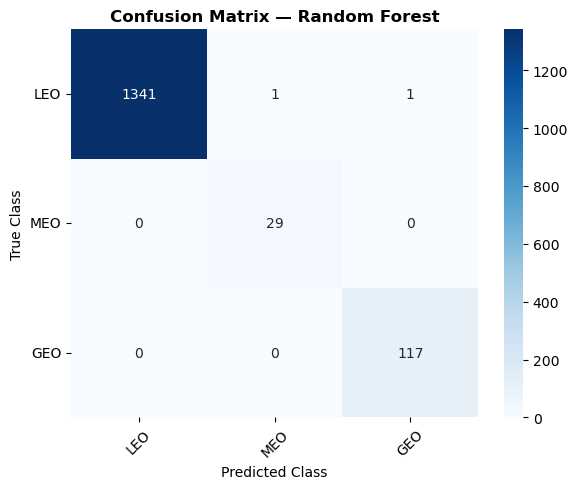

In [32]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics         import confusion_matrix, classification_report, accuracy_score
from sklearn.pipeline        import Pipeline
print(" scikit-learn imported")
confusion_matrix(y_test, y_pred, labels=CLASSES)
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred, labels=CLASSES), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=10)
plt.ylabel('True Class', fontsize=10)
plt.xticks(ticks=np.arange(len(CLASSES)) + 0.5, labels=CLASSES, rotation=45)
plt.yticks(ticks=np.arange(len(CLASSES)) + 0.5, labels=CLASSES, rotation=0)
plt.tight_layout()
plt.show()



### 5.6 Feature Importance

Feature Importances (Random Forest):
  period_min               : 0.4417  (44.2%)
  inclination_deg          : 0.2903  (29.0%)
  launch_mass_kg           : 0.2679  (26.8%)


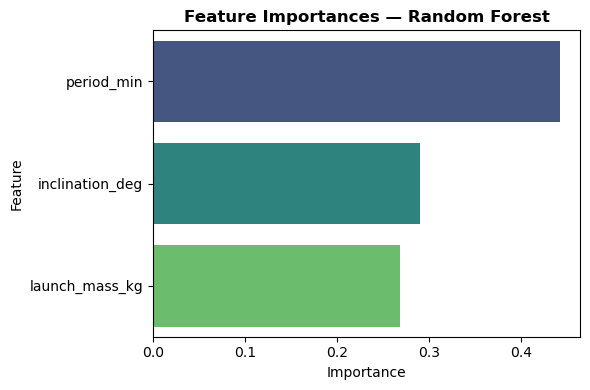

In [33]:
rf_model    = results['Random Forest']['pipe'].named_steps['clf']
importances = rf_model.feature_importances_
feat_imp    = pd.Series(importances, index=FEATURES).sort_values(ascending=False)

print("Feature Importances (Random Forest):")
for feat, imp in feat_imp.items():
    print(f"  {feat:<25}: {imp:.4f}  ({imp*100:.1f}%)")
plt.figure(figsize=(6,4))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Feature Importances — Random Forest', fontsize=12, fontweight='bold')
plt.xlabel('Importance', fontsize=10)
plt.ylabel('Feature', fontsize=10)
plt.tight_layout()
plt.show()

---
## 6. Analytical Visualization — Technical Report Charts

> All charts exported at 200 DPI for professional technical report inclusion.


### 6.1 Chart 1 — Comparative Bar Chart
> Satellite count and mass by regional operators (Turkey, Kazakhstan, Iran, Azerbaijan)


=== Regional Satellite Count and Mass ===


,satellite_count,total_launch_mass_kg
operator_country,,
Turkey,14,1374.03
Kazakhstan,6,1124.67
Iran,2,665.00
Azerbaijan,2,6.75


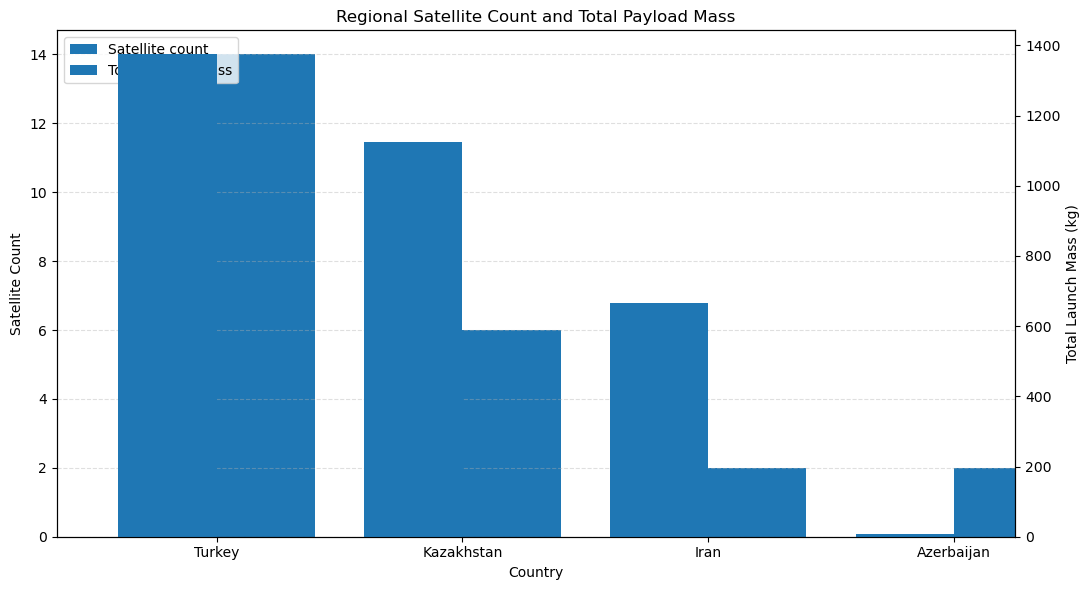

Saved: chart1_regional_count_mass.png


In [35]:
# Chart 1 — Comparative bar chart: regional satellite count and mass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

viz_df = pd.read_csv("satellites_normalized.csv")
regional_countries = ['Turkey', 'Kazakhstan', 'Iran', 'Azerbaijan']
region = viz_df[viz_df['operator_country'].isin(regional_countries)].copy()

regional_summary = (
    region.groupby('operator_country')
    .agg(
        satellite_count=('official_name', 'count'),
        total_launch_mass_kg=('launch_mass_kg', 'sum')
    )
    .reindex(regional_countries)
    .fillna(0)
)

print("=== Regional Satellite Count and Mass ===")
display(regional_summary.round(2))

fig, ax1 = plt.subplots(figsize=(11, 6))

regional_summary['satellite_count'].plot(kind='bar', ax=ax1, position=0, width=0.4, label='Satellite count')
ax1.set_ylabel('Satellite Count')
ax1.set_xlabel('Country')
ax1.tick_params(axis='x', rotation=0)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
regional_summary['total_launch_mass_kg'].plot(kind='bar', ax=ax2, position=1, width=0.4, label='Total launch mass')
ax2.set_ylabel('Total Launch Mass (kg)')

ax1.set_title('Regional Satellite Count and Total Payload Mass')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('chart1_regional_count_mass.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: chart1_regional_count_mass.png")

### 6.2 Chart 2 — Scatter Plot
> Perigee vs. Apogee with points colored by Orbit Class — orbital spacing visualization


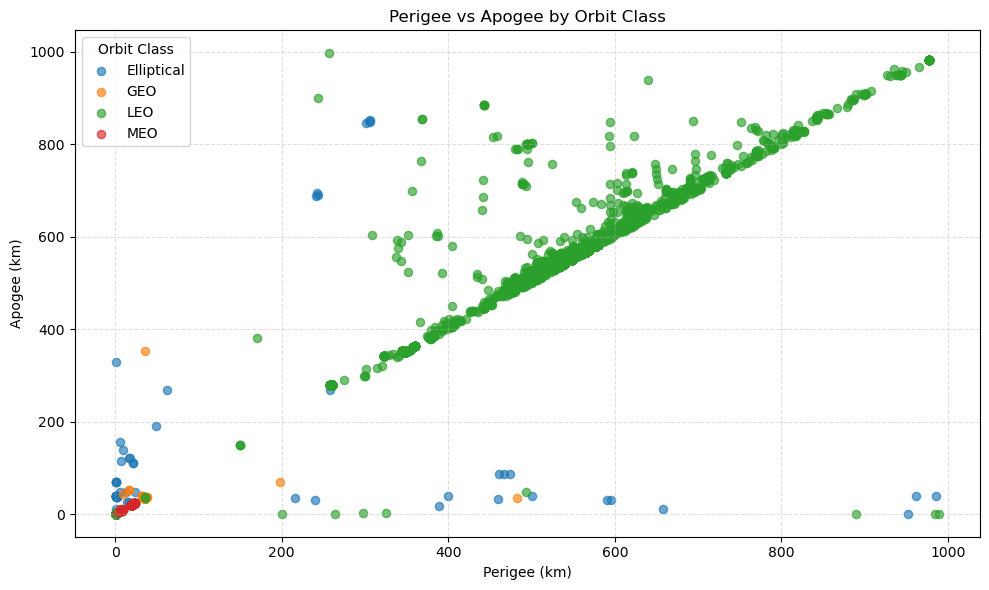

Saved: chart2_perigee_vs_apogee.png


In [36]:
# Chart 2 — Scatter plot: Perigee vs Apogee by orbit class
import pandas as pd
import matplotlib.pyplot as plt

viz_df = pd.read_csv("satellites_normalized.csv")
scatter_df = viz_df.dropna(subset=['perigee_km', 'apogee_km', 'orbit_class']).copy()
scatter_df['orbit_class'] = scatter_df['orbit_class'].replace({'LEo': 'LEO'})

plt.figure(figsize=(10, 6))

for orbit_class, group in scatter_df.groupby('orbit_class'):
    plt.scatter(
        group['perigee_km'],
        group['apogee_km'],
        s=35,
        alpha=0.65,
        label=orbit_class
    )

plt.title('Perigee vs Apogee by Orbit Class')
plt.xlabel('Perigee (km)')
plt.ylabel('Apogee (km)')
plt.legend(title='Orbit Class')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart2_perigee_vs_apogee.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: chart2_perigee_vs_apogee.png")

### 6.3 Chart 3 — Correlation Heatmap
> Correlation between Inclination, Mass, Expected Lifetime, and other orbital parameters


=== Correlation Matrix ===


,inclination_deg,launch_mass_kg,expected_lifetime_yrs
inclination_deg,1.000,-0.061,-0.524
launch_mass_kg,-0.061,1.000,-0.037
expected_lifetime_yrs,-0.524,-0.037,1.000


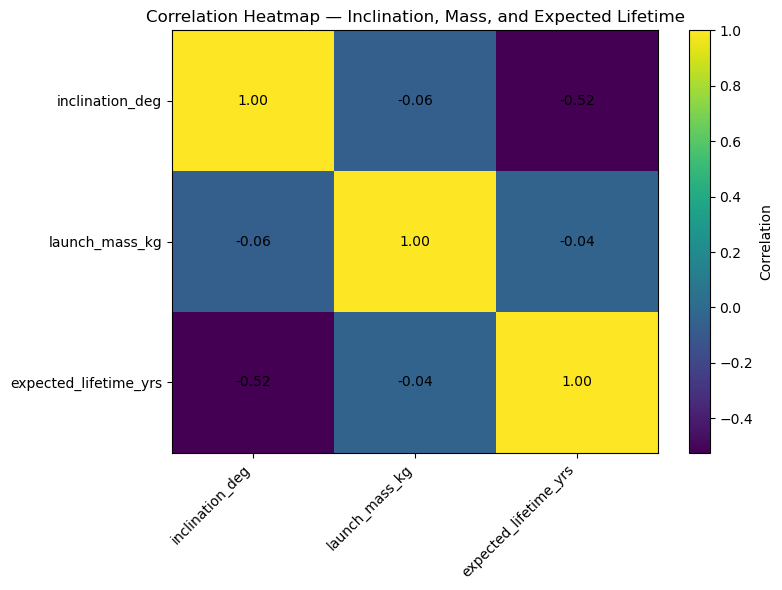

Saved: chart3_correlation_heatmap.png


In [37]:
# Chart 3 — Correlation heatmap: inclination, mass, and expected lifetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

viz_df = pd.read_csv("satellites_normalized.csv")

corr_cols = [
    'inclination_deg',
    'launch_mass_kg',
    'expected_lifetime_yrs'
]

corr = viz_df[corr_cols].corr()
print("=== Correlation Matrix ===")
display(corr.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, aspect='auto')

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')

plt.colorbar(im, ax=ax, label='Correlation')
ax.set_title('Correlation Heatmap — Inclination, Mass, and Expected Lifetime')
plt.tight_layout()
plt.savefig('chart3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: chart3_correlation_heatmap.png")

### 6.4 Chart 4 — Time-Series
> Growth of commercial satellite presence in the Caspian region vs. global trends


=== Commercial Satellite Growth: Region vs Global ===


,year,global_annual_commercial,regional_annual_commercial,global_cumulative_commercial,regional_cumulative_commercial,global_growth_index,regional_growth_index
9,2009,25,0,163,1,1018.75,100.0
10,2010,21,0,184,1,1150.00,100.0
11,2011,31,1,215,2,1343.75,200.0
12,2012,23,0,238,2,1487.50,200.0
13,2013,32,0,270,2,1687.50,200.0
14,2014,49,2,319,4,1993.75,400.0
15,2015,53,1,372,5,2325.00,500.0
16,2016,32,0,404,5,2525.00,500.0
17,2017,145,0,549,5,3431.25,500.0
18,2018,163,1,712,6,4450.00,600.0


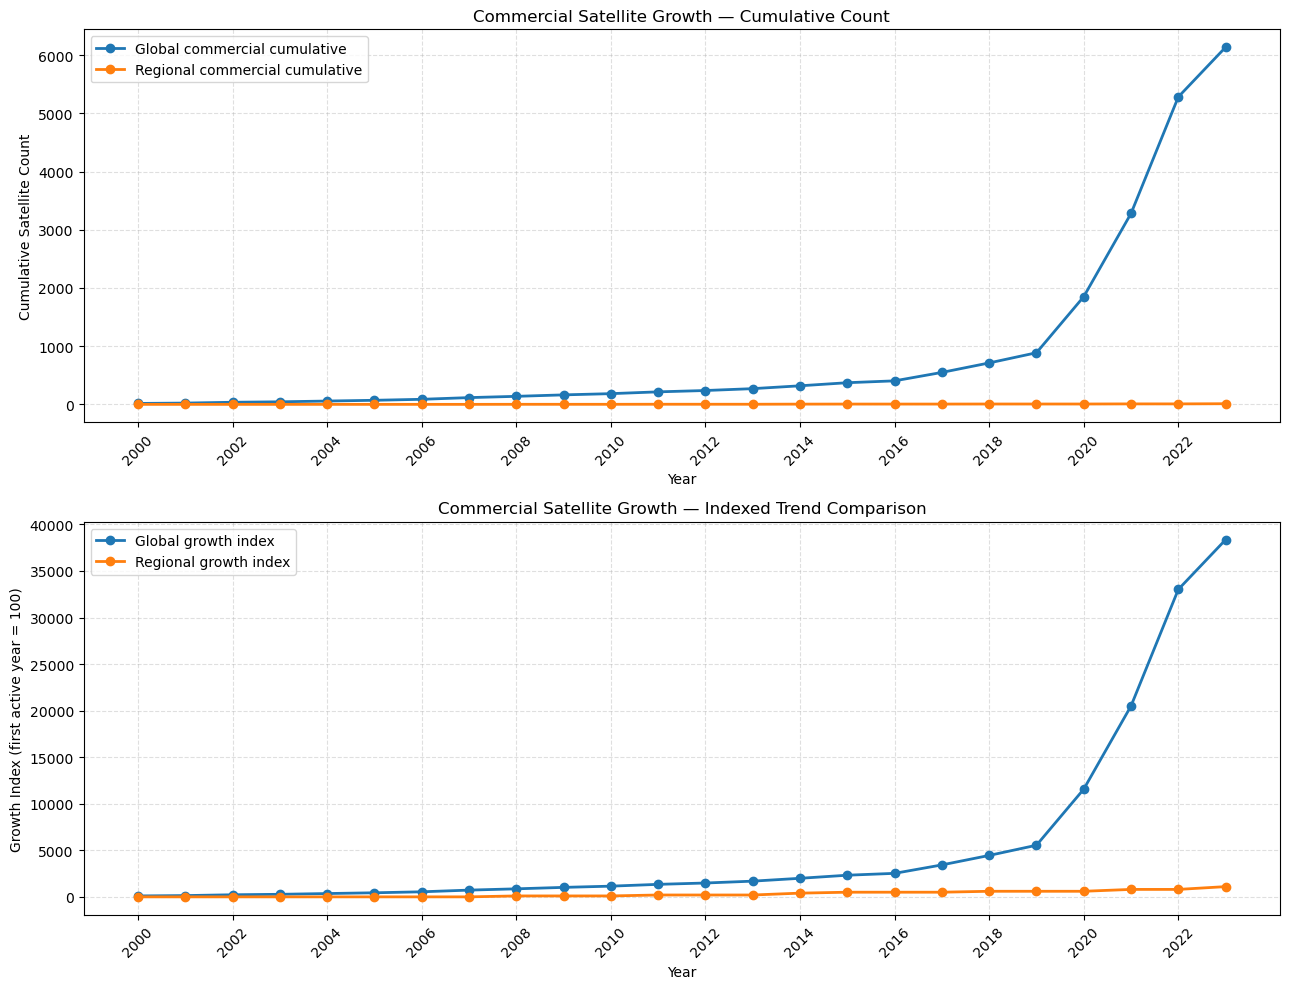

Saved: chart4_commercial_growth_region_vs_global.png
Saved: chart4_commercial_growth_region_vs_global.csv


In [38]:
# Chart 4 — Time-series: commercial satellite growth in the region vs global trends
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

viz_df = pd.read_csv("satellites_normalized.csv")

viz_df['date_of_launch'] = pd.to_datetime(viz_df['date_of_launch'], errors='coerce')
viz_df['year'] = viz_df['date_of_launch'].dt.year
viz_df = viz_df[viz_df['year'].between(2000, 2023)].copy()

regional_countries = ['Azerbaijan', 'Turkey', 'Kazakhstan', 'Iran']

# Commercial filter. This works for values such as "Commercial", "Commercial/Government", etc.
commercial_df = viz_df[viz_df['user_type'].astype(str).str.contains('Commercial', case=False, na=False)].copy()
regional_commercial = commercial_df[commercial_df['operator_country'].isin(regional_countries)].copy()

years = pd.Index(range(2000, 2024), name='year')

global_annual = commercial_df.groupby('year').size().reindex(years, fill_value=0)
regional_annual = regional_commercial.groupby('year').size().reindex(years, fill_value=0)

global_cumulative = global_annual.cumsum()
regional_cumulative = regional_annual.cumsum()

# Indexed growth makes regional and global trends comparable despite different scale.
def growth_index(series):
    first_non_zero = series[series > 0]
    if first_non_zero.empty:
        return series * 0
    base_value = first_non_zero.iloc[0]
    return (series / base_value) * 100

global_index = growth_index(global_cumulative)
regional_index = growth_index(regional_cumulative)

growth_table = pd.DataFrame({
    'global_annual_commercial': global_annual,
    'regional_annual_commercial': regional_annual,
    'global_cumulative_commercial': global_cumulative,
    'regional_cumulative_commercial': regional_cumulative,
    'global_growth_index': global_index,
    'regional_growth_index': regional_index
}).reset_index()

print("=== Commercial Satellite Growth: Region vs Global ===")
display(growth_table.tail(15))

growth_table.to_csv('chart4_commercial_growth_region_vs_global.csv', index=False)

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# A) Cumulative count comparison
axes[0].plot(years, global_cumulative, marker='o', linewidth=2, label='Global commercial cumulative')
axes[0].plot(years, regional_cumulative, marker='o', linewidth=2, label='Regional commercial cumulative')
axes[0].set_title('Commercial Satellite Growth — Cumulative Count')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Cumulative Satellite Count')
axes[0].grid(True, linestyle='--', alpha=0.4)
axes[0].legend()

# B) Indexed trend comparison
axes[1].plot(years, global_index, marker='o', linewidth=2, label='Global growth index')
axes[1].plot(years, regional_index, marker='o', linewidth=2, label='Regional growth index')
axes[1].set_title('Commercial Satellite Growth — Indexed Trend Comparison')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Growth Index (first active year = 100)')
axes[1].grid(True, linestyle='--', alpha=0.4)
axes[1].legend()

for ax in axes:
    ax.set_xticks(list(range(2000, 2024, 2)))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('chart4_commercial_growth_region_vs_global.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: chart4_commercial_growth_region_vs_global.png")
print("Saved: chart4_commercial_growth_region_vs_global.csv")